# COVID-19 Data Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##  Load Dataset

In [ ]:
df = pd.read_csv("data(Covidd.csv)")

In [3]:
df

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
35151,2020-07-27,West Bank and Gaza,10621,78,3752,6791,152,2,0,Eastern Mediterranean
35152,2020-07-27,Western Sahara,10,1,8,1,0,0,0,Africa
35153,2020-07-27,Yemen,1691,483,833,375,10,4,36,Eastern Mediterranean
35154,2020-07-27,Zambia,4552,140,2815,1597,71,1,465,Africa


## Data Exploration

In [4]:
df.shape

(35156, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [6]:
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04,35156.00000,35156.000000,35156.000000
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04,469.36375,18.603339,269.315593
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04,3005.86754,115.706351,2068.063852
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00,0.00000,-1918.000000,-16298.000000
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.00000,0.000000,0.000000
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01,2.00000,0.000000,0.000000
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03,75.00000,1.000000,20.000000
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,77255.00000,3887.000000,140050.000000


## Data Cleaning

In [9]:
# check missing values

df.isnull().sum()

Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
New cases         0
New deaths        0
New recovered     0
WHO Region        0
dtype: int64

## 4. Data Cleaning

In [11]:
df.dtypes

Date              object
Country/Region    object
Confirmed          int64
Deaths             int64
Recovered          int64
Active             int64
New cases          int64
New deaths         int64
New recovered      int64
WHO Region        object
dtype: object

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

Date                188
Country/Region      187
Confirmed         10732
Deaths             3598
Recovered          7649
Active             8440
New cases          2800
New deaths          715
New recovered      2276
WHO Region            6
dtype: int64

In [13]:
# covert object into datetime 
df['Date']=pd.to_datetime(df['Date'])

In [14]:
df['Date'].dtype

dtype('<M8[ns]')

In [15]:
df['Month']= df['Date'].dt.month

In [16]:
df['Year']= df['Date'].dt.year

In [17]:
df['Country/Region'].value_counts()

Country/Region
Afghanistan    188
Pakistan       188
Nepal          188
Netherlands    188
New Zealand    188
              ... 
Georgia        188
Germany        188
Ghana          188
Greece         188
Zimbabwe       188
Name: count, Length: 187, dtype: int64

In [18]:
df.dtypes

Date              datetime64[ns]
Country/Region            object
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
New cases                  int64
New deaths                 int64
New recovered              int64
WHO Region                object
Month                      int32
Year                       int32
dtype: object

Which year had the highest number of confirmed cases?

## 5. Exploratory Data Analysis (EDA)

In [19]:
df.groupby('Year')['Confirmed'].sum()

Year
2020    828508482
Name: Confirmed, dtype: int64

Which month recorded the highest number of confirmed cases?

In [20]:
df.groupby('Month')['Confirmed'].sum()

Month
1        38534
2      1663437
3      9002815
4     63391662
5    144990399
6    246525787
7    362895848
Name: Confirmed, dtype: int64

In [21]:
df.groupby('Month')['Recovered'].sum()

Month
1          838
2       363669
3      2644372
4     15944020
5     52876838
6    116984268
7    199594224
Name: Recovered, dtype: int64

In [22]:
df['Year'].value_counts()

Year
2020    35156
Name: count, dtype: int64

In [23]:
# Deaths by month
df.groupby('Month')['Deaths'].sum()

Month
1         889
2       46875
3      397601
4     4311214
5     9609604
6    13309053
7    15709667
Name: Deaths, dtype: int64

EDA

In [24]:
df.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

Country/Region
US                224345948
Brazil             89524967
Russia             45408411
India              40883464
Spain              27404045
United Kingdom     26748587
Italy              26745145
France             21210926
Germany            21059152
Iran               19339267
Name: Confirmed, dtype: int64

In [25]:
df.groupby('Country/Region')['Recovered'].sum().sort_values(ascending=False).head(10)

Country/Region
US         56353416
Brazil     54492873
Russia     25120448
India      23783720
Germany    17107839
Italy      15673910
Iran       15200895
Spain      15093583
Turkey     13345389
Chile      13292593
Name: Recovered, dtype: int64

In [26]:
df.groupby('WHO Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

WHO Region
Americas                 402261194
Europe                   248879793
Eastern Mediterranean     74082892
South-East Asia           55118365
Western Pacific           26374411
Africa                    21791827
Name: Confirmed, dtype: int64

In [27]:
df[['Confirmed','Deaths','Recovered','Active']].describe()

,Confirmed,Deaths,Recovered,Active
count,3.515600e+04,35156.000000,3.515600e+04,3.515600e+04
mean,2.356663e+04,1234.068239,1.104813e+04,1.128443e+04
std,1.499818e+05,7437.238354,6.454640e+04,8.997149e+04
min,0.000000e+00,0.000000,0.000000e+00,-2.000000e+00
25%,1.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,2.500000e+02,4.000000,3.300000e+01,8.500000e+01
75%,3.640250e+03,78.250000,1.286250e+03,1.454000e+03
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [28]:
top_confirmed = (
    df.groupby('Country/Region')['Confirmed']
      .max()
      .sort_values(ascending=False)
      .head(10)
)

top_confirmed

Country/Region
US                4290259
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     301708
Iran               293606
Name: Confirmed, dtype: int64

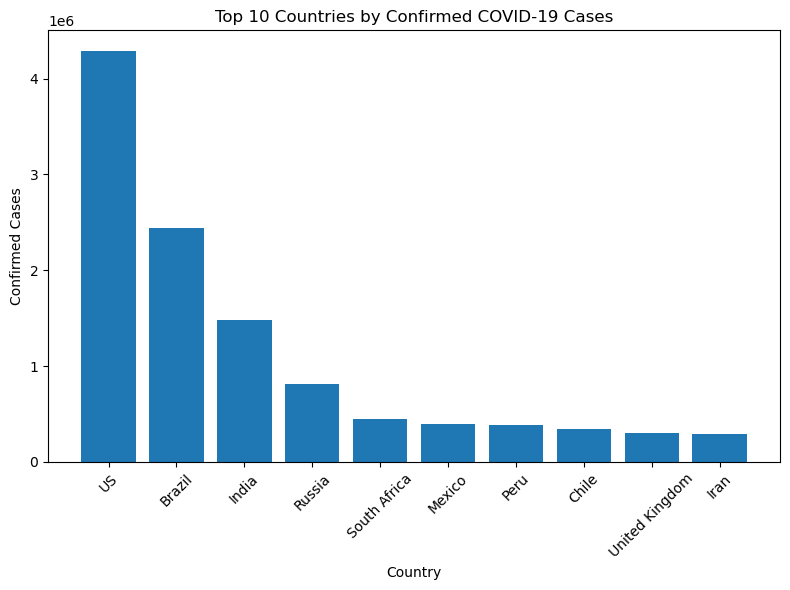

In [73]:
# using matplot
plt.figure(figsize=(8,6))

plt.bar(top_confirmed.index,
        top_confirmed.values)

plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

The United States recorded the highest number of confirmed COVID-19 cases, followed by Brazil and India. These countries were among the most severely affected during the first wave of the pandemic.

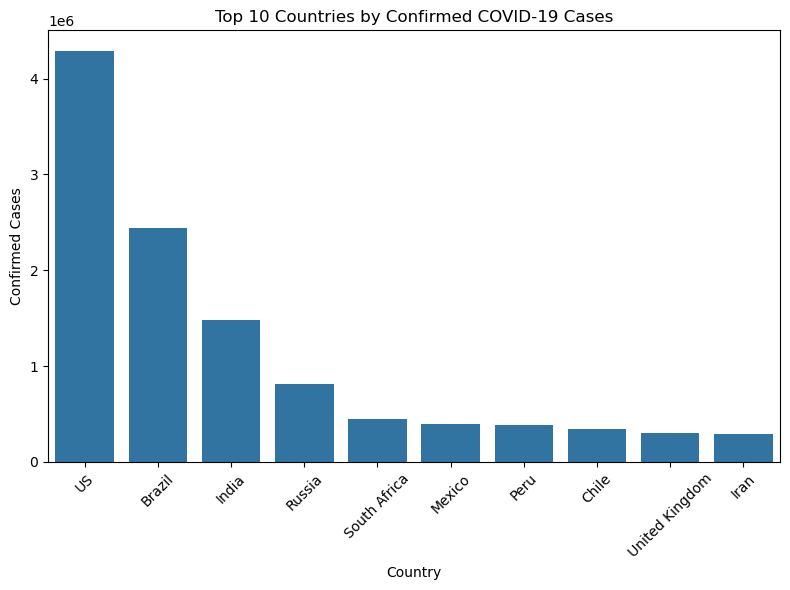

In [72]:
# using seaborn

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_confirmed.index,
    y=top_confirmed.values
)

plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
top_deaths = (
    df.groupby('Country/Region')['Deaths']
      .max()
      .sort_values(ascending=False)
      .head(10)
)
top_deaths

Country/Region
US                148011
Brazil             87618
United Kingdom     45844
Mexico             44022
Italy              35112
India              33408
France             30212
Spain              28752
Peru               18418
Iran               15912
Name: Deaths, dtype: int64

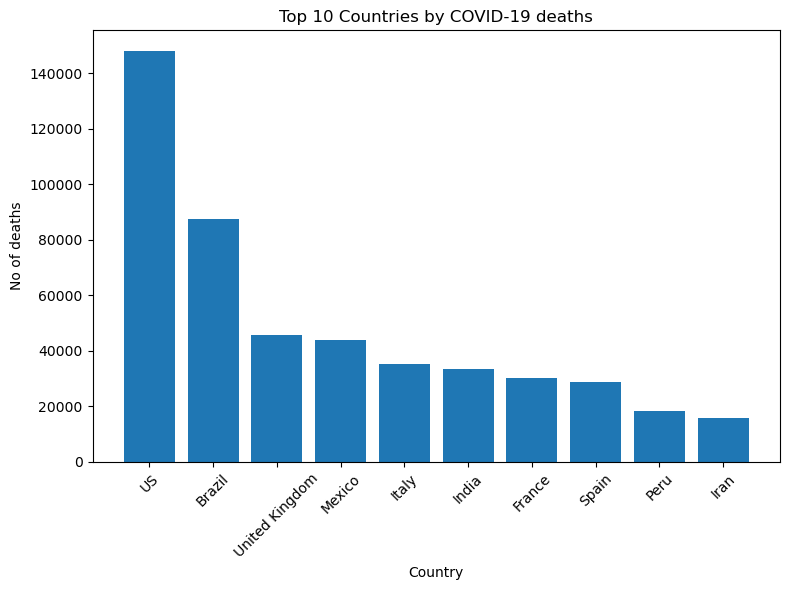

In [71]:
# using matplot
plt.figure(figsize=(8,6))

plt.bar(top_deaths.index,
        top_deaths.values)

plt.title('Top 10 Countries by COVID-19 deaths')
plt.xlabel('Country')
plt.ylabel('No of deaths')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

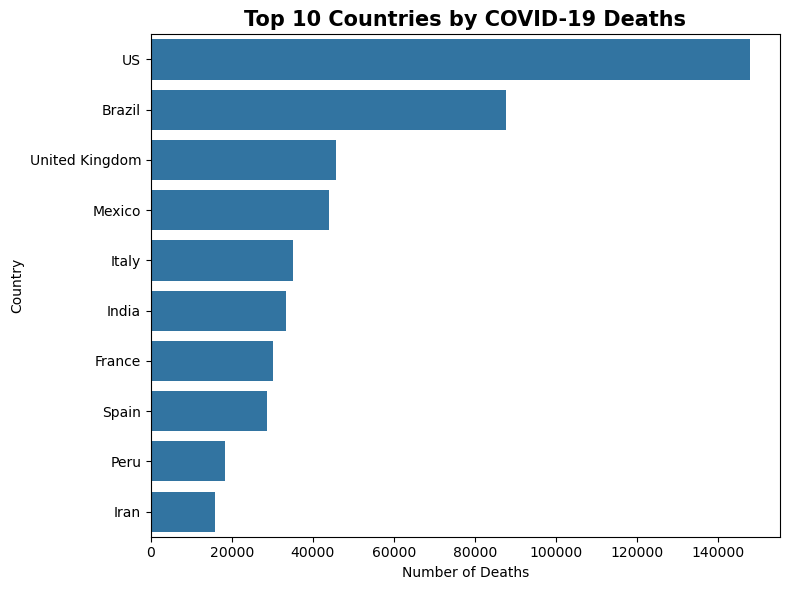

In [70]:
# seaborn

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_deaths.values,
    y=top_deaths.index
)

plt.title('Top 10 Countries by COVID-19 Deaths', fontsize=15, fontweight='bold')

plt.xlabel('Number of Deaths')

plt.ylabel('Country')

plt.tight_layout()

plt.show()

### Insight

The United States reported the highest number of COVID-19 deaths during the selected period. Brazil, the United Kingdom, and Mexico also experienced significant mortality, highlighting the severe impact of the pandemic in these countries.

In [45]:
monthly_cases = (
    df.groupby('Month')['Confirmed']
      .max().sort_index()
)

monthly_cases

Month
1       9802
2      79356
3     188724
4    1072667
5    1799124
6    2636414
7    4290259
Name: Confirmed, dtype: int64

In [46]:
df.columns

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region', 'Month',
       'Year'],
      dtype='object')

In [47]:
month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul'
}

df['Month_Name'] = df['Month'].map(month_map)

In [48]:
monthly_cases1 = (
    df.groupby('Month_Name')['Confirmed']
      .max()
    .sort_index()
)

monthly_cases1

Month_Name
Apr    1072667
Feb      79356
Jan       9802
Jul    4290259
Jun    2636414
Mar     188724
May    1799124
Name: Confirmed, dtype: int64

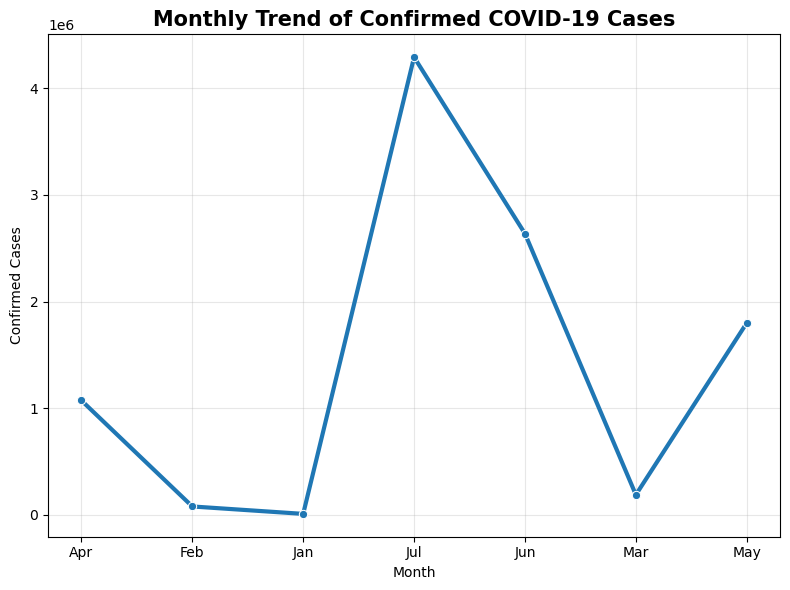

In [49]:
plt.figure(figsize=(8,6))

sns.lineplot(
    x=monthly_cases1.index,
    y=monthly_cases1.values,
    marker='o',
    linewidth=3
)

plt.title('Monthly Trend of Confirmed COVID-19 Cases',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Month')
plt.ylabel('Confirmed Cases')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


### Insight

Confirmed COVID-19 cases increased steadily from January to July 2020, showing the rapid spread of the virus during the first wave of the pandemic.

In [50]:
monthly_deaths = (
    df.groupby('Month')['Deaths']
      .max()
)
monthly_deaths

Month
1       213
2      2837
3     12428
4     64256
5    105364
6    127432
7    148011
Name: Deaths, dtype: int64

In [51]:
monthly_deaths1 = (
    df.groupby('Month_Name')['Deaths']
      .max()
)
monthly_deaths1

Month_Name
Apr     64256
Feb      2837
Jan       213
Jul    148011
Jun    127432
Mar     12428
May    105364
Name: Deaths, dtype: int64

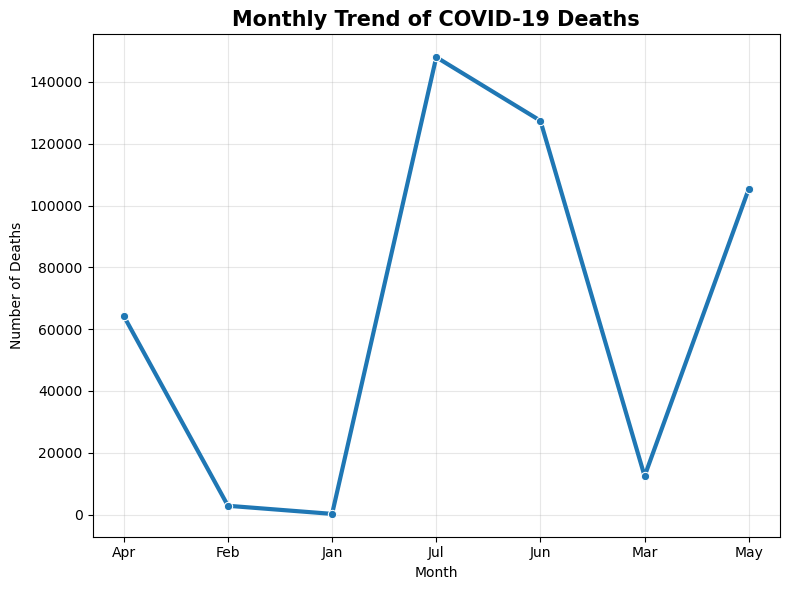

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.lineplot(
    x=monthly_deaths1.index,
    y=monthly_deaths1.values,
    marker='o',
    linewidth=3
)

plt.title('Monthly Trend of COVID-19 Deaths',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Month')
plt.ylabel('Number of Deaths')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Insight

COVID-19 deaths increased consistently from January to July 2020, reflecting the growing impact of the pandemic as confirmed cases continued to rise worldwide.

In [53]:
top_active = (
    df.groupby('Country/Region')['Active']
      .max()
      .sort_values(ascending=False)
      .head(10)
)
top_active

Country/Region
US                2816444
Brazil             583080
India              495499
United Kingdom     254427
Russia             245382
South Africa       173590
Colombia           117163
France             108928
Pakistan           108642
Peru               108616
Name: Active, dtype: int64

In [54]:
#  matplotlib


In [55]:
# daily new cases
df.groupby('Date')['New cases'].sum()

Date
2020-01-22         0
2020-01-23        99
2020-01-24       287
2020-01-25       493
2020-01-26       684
               ...  
2020-07-23    282756
2020-07-24    281164
2020-07-25    255545
2020-07-26    204606
2020-07-27    228693
Name: New cases, Length: 188, dtype: int64

In [56]:
# correlation
df[['Confirmed','Deaths','Recovered','Active']].corr()

,Confirmed,Deaths,Recovered,Active
Confirmed,1.000000,0.912016,0.894418,0.949940
Deaths,0.912016,1.000000,0.761093,0.891647
Recovered,0.894418,0.761093,1.000000,0.710665
Active,0.949940,0.891647,0.710665,1.000000


In [57]:
df['Date'].min(), df['Date'].max()

(Timestamp('2020-01-22 00:00:00'), Timestamp('2020-07-27 00:00:00'))

In [58]:
daily_deaths = (
    df.groupby('Date')['New deaths']
      .sum()
)
daily_deaths

Date
2020-01-22       0
2020-01-23       1
2020-01-24       8
2020-01-25      16
2020-01-26      14
              ... 
2020-07-23    9966
2020-07-24    6144
2020-07-25    4867
2020-07-26    4104
2020-07-27    5415
Name: New deaths, Length: 188, dtype: int64

In [59]:
daily_cases = (
    df.groupby('Date')['New cases']
      .sum()
)
daily_cases

Date
2020-01-22         0
2020-01-23        99
2020-01-24       287
2020-01-25       493
2020-01-26       684
               ...  
2020-07-23    282756
2020-07-24    281164
2020-07-25    255545
2020-07-26    204606
2020-07-27    228693
Name: New cases, Length: 188, dtype: int64

In [60]:
monthly_recovered = (
    df.groupby('Month')['Recovered']
      .max()
      .sort_index()
)
monthly_recovered

Month
1        211
2      37868
3      74645
4     153947
5     444758
6     788318
7    1846641
Name: Recovered, dtype: int64

In [61]:
monthly_recovered1 = (
    df.groupby('Month_Name')['Recovered']
      .max()
      .sort_index()
)
monthly_recovered1

Month_Name
Apr     153947
Feb      37868
Jan        211
Jul    1846641
Jun     788318
Mar      74645
May     444758
Name: Recovered, dtype: int64

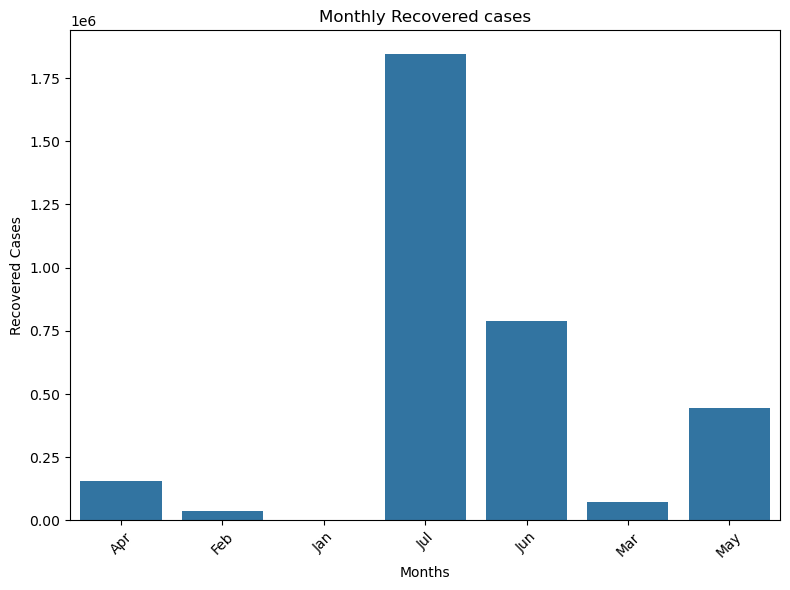

In [62]:
# Graph
plt.figure(figsize=(8,6))

sns.barplot(
    x=monthly_recovered1.index,
    y=monthly_recovered1.values
)

plt.title('Monthly Recovered cases')
plt.xlabel('Months')
plt.ylabel('Recovered Cases')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [63]:
Region_confirmed = (
    df.groupby('WHO Region')['Confirmed']
      .max()
      .sort_values(ascending=False)
)

Region_confirmed

WHO Region
Americas                 4290259
South-East Asia          1480073
Europe                    816680
Africa                    452529
Eastern Mediterranean     293606
Western Pacific            86783
Name: Confirmed, dtype: int64

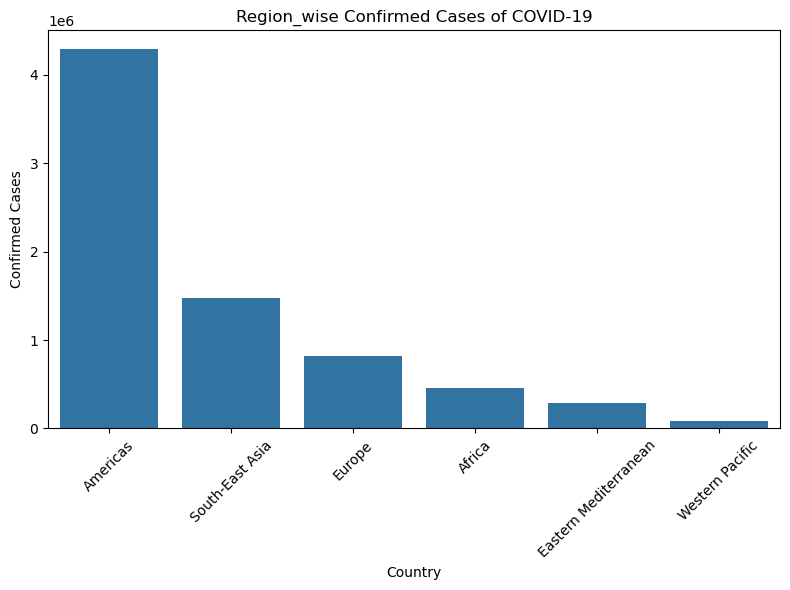

In [64]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=Region_confirmed.index,
    y=Region_confirmed.values
)

plt.title('Region_wise Confirmed Cases of COVID-19')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [65]:
Region_Deaths = (
    df.groupby('WHO Region')['Deaths']
      .max()
      .sort_values(ascending=False)
)
Region_Deaths

WHO Region
Americas                 148011
Europe                    45844
South-East Asia           33408
Eastern Mediterranean     15912
Africa                     7067
Western Pacific            4656
Name: Deaths, dtype: int64

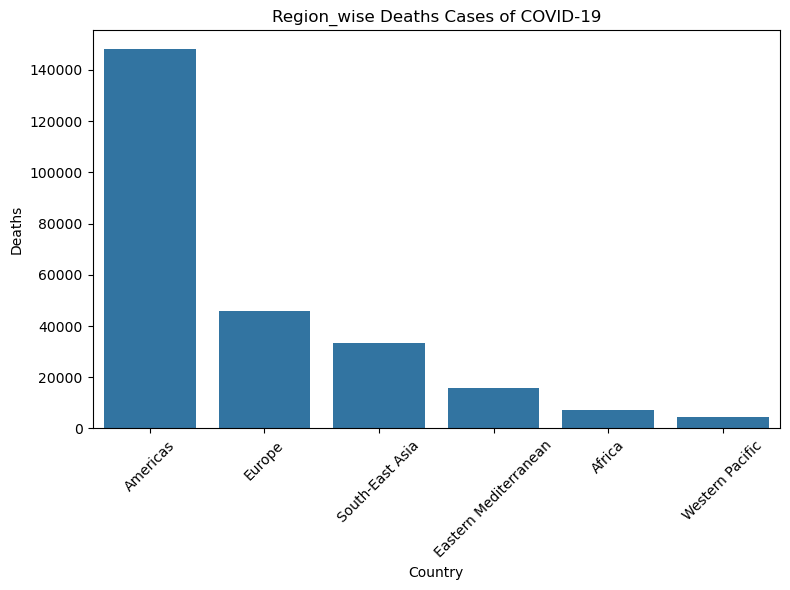

In [66]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=Region_Deaths.index,
    y=Region_Deaths.values
)

plt.title('Region_wise Deaths Cases of COVID-19')
plt.xlabel('Country')
plt.ylabel('Deaths')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

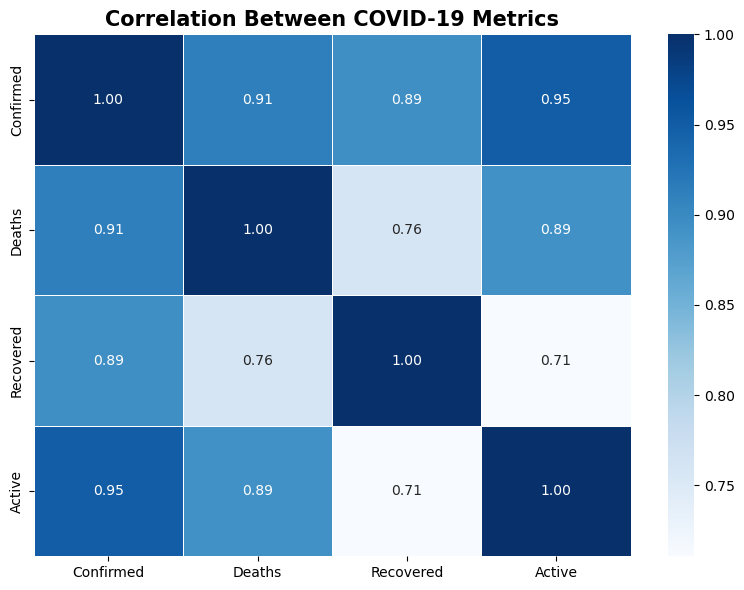

In [67]:
plt.figure(figsize=(8,6))

correlation = df[['Confirmed', 'Deaths', 'Recovered', 'Active']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between COVID-19 Metrics',
          fontsize=15,
          fontweight='bold')

plt.tight_layout()
plt.show()

### Insight

The correlation heatmap shows a strong positive relationship between confirmed cases, deaths, recoveries, and active cases. 
This indicates that countries with more confirmed cases generally experienced higher numbers of deaths and recoveries.

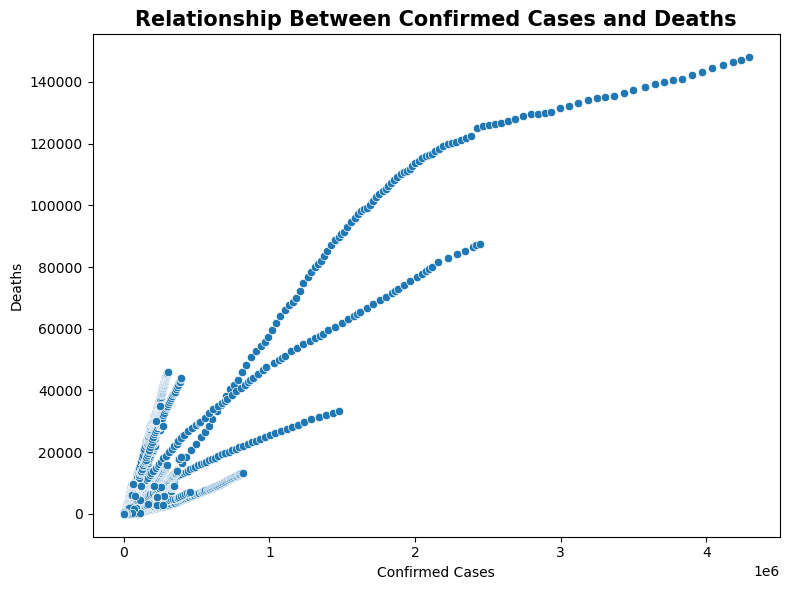

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Confirmed',
    y='Deaths'
)

plt.title('Relationship Between Confirmed Cases and Deaths',
          fontsize=15,
          fontweight='bold')

plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')

plt.tight_layout()
plt.show()

### Insight

The scatter plot indicates a positive relationship between confirmed cases and deaths. 
Countries with a larger number of confirmed cases generally reported higher death counts.

## Conclusion

This analysis explored the global spread of COVID-19 between January and July 2020. The findings show that confirmed cases, deaths, and recoveries increased significantly during this period. The analysis also highlighted the countries and WHO regions most affected by the pandemic and demonstrated strong correlations among key COVID-19 metrics.